In [1]:
# Load the necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### step-1 Data Preprocessing

In [2]:
df = pd.read_csv("human voice clustering.zip") # load the data using pandas function

In [3]:
df.head() # check the starting few rows in our data set

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
0,2247.331739,1158.537748,1870.415462,370.405241,21.440710,0.036879,4419.438073,0.169241,0.082552,1592.1033,...,21.736240,2.303085,8.983318,-17.410305,9.115154,0.301804,10.452693,-3.080832,10.146248,0
1,1790.719889,996.554825,1757.898617,410.710318,21.513383,0.018936,3635.742188,0.108068,0.055477,1112.6351,...,13.937135,-0.953942,10.831742,-0.088775,10.297690,-7.281142,10.926579,-0.450248,8.489134,0
2,1977.923363,1010.148667,1747.099555,461.458379,20.476283,0.032616,3873.291016,0.144633,0.060388,1557.5225,...,14.900779,0.260098,14.031009,-0.420670,10.810292,-0.199829,11.986182,3.372986,9.285437,0
3,2037.765550,1311.440630,1745.224852,419.056484,19.516014,0.028482,3826.584507,0.148933,0.029559,1481.0868,...,15.957924,-1.486122,14.461978,-8.479608,12.550333,3.997028,9.912608,-6.946966,10.574301,0
4,1739.383829,1092.623322,1623.135563,450.088465,20.260620,0.025737,3452.903892,0.117961,0.069078,1424.5352,...,15.105562,-3.366364,13.943447,-6.561539,11.944948,1.410639,13.110976,-3.252258,9.866687,0


In [4]:
df.shape # check the shape of our data set how many rows and how many columns are present in our dataset

(16148, 44)

In [5]:
df.info() # check the information 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew            16148 non-null  float64
 14  spectral_kurtosis     

## we checked our dataset all columns are numerical and no missing values are present in our data set

In [6]:
df.isnull().sum() # also we here clearly see that there is no missing value in our data set using isnull function

mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean                0
mfcc_9_std    

In [7]:
# check the discreption of the data set what is the minimum value or maximum value what is the average and what values are present in our dataset 
df.describe()

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
count,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,...,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000,16148.000000
mean,1709.269730,1027.564673,1584.195931,432.492328,20.395652,0.023086,3281.808257,0.118088,0.084759,1461.624198,...,13.537739,-0.533815,12.515116,-8.933890,10.982858,0.880024,9.721608,-6.711788,9.536517,0.642804
std,315.558063,286.303662,126.360465,78.723202,1.628596,0.010027,526.824341,0.037707,0.022814,287.763342,...,2.438230,5.593673,2.354020,5.315098,1.886158,4.314862,1.794407,4.069641,1.574890,0.479188
min,719.559285,194.998983,1106.939002,199.321584,15.154801,0.001816,1310.661765,0.027727,0.022425,359.391170,...,5.826506,-20.188465,5.459179,-26.082537,5.594748,-13.585977,4.378153,-26.402317,4.686154,0.000000
25%,1475.078509,829.195585,1503.301521,379.552391,19.775875,0.015567,2911.427574,0.089729,0.067508,1279.141250,...,11.861280,-4.521667,10.753869,-12.666048,9.641137,-2.050272,8.455685,-9.676477,8.432545,0.000000
50%,1703.038854,1048.531356,1583.959951,423.121818,20.759579,0.021737,3293.459741,0.116623,0.083121,1484.461250,...,13.306489,-0.625990,12.279825,-8.732289,10.796652,0.949182,9.595896,-6.598702,9.433592,1.000000
75%,1921.202685,1233.451527,1665.806788,477.631817,21.516436,0.029175,3637.773811,0.144095,0.100465,1662.883350,...,15.044193,3.136063,14.099204,-5.328175,12.153640,3.896141,10.863349,-3.575793,10.508087,1.000000
max,3059.390150,1912.173446,2046.070801,724.361505,24.907725,0.072172,5451.099537,0.270710,0.187577,2454.724000,...,26.693924,19.610289,22.717190,6.013963,19.685654,16.436730,17.380630,6.187790,17.941544,1.000000


## we clearly see that in data description our data is not in same range so we want to standardize or normalize the our data

In [8]:
# load the library
from sklearn.preprocessing import StandardScaler

In [9]:
st = StandardScaler()
x_scaled = st.fit_transform(df.drop('label', axis=1))

## Converting All Features to the Same Range (Normalization)

### Brings all features to mean = 0, std = 1

In [10]:
# Convert to DataFrame with same column names
x_scaled = pd.DataFrame(x_scaled,columns=df.drop('label',axis=1).columns)

In [11]:
x_scaled
y = df["label"]

## we have 44 features and not all features are import so we do feature engineering

## Feature Engineering & Feature Selection

### Feature Selection Methods

### 1. Filter Method — Correlation Analysis

In [12]:
df.corr()

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
mean_spectral_centroid,1.000000,0.709942,0.738259,-0.009975,0.397686,0.665825,0.958090,0.923811,-0.082043,0.657368,...,0.224346,-0.043253,0.180304,-0.402173,0.068883,0.118551,0.351369,-0.241585,0.099590,-0.211159
std_spectral_centroid,0.709942,1.000000,0.379087,0.473400,0.452654,0.518704,0.573388,0.796688,0.249653,0.402465,...,0.179540,-0.051216,0.115796,-0.325763,0.065061,0.042224,0.262833,-0.248421,0.044976,-0.294790
mean_spectral_bandwidth,0.738259,0.379087,1.000000,-0.069785,0.265028,0.452479,0.851114,0.552460,-0.122605,0.382114,...,0.261054,0.066931,0.095552,-0.252160,0.141841,0.058722,0.262232,-0.085878,0.115974,-0.163957
std_spectral_bandwidth,-0.009975,0.473400,-0.069785,1.000000,0.263187,0.138957,-0.049660,0.143204,0.459810,-0.146245,...,0.043090,-0.166718,-0.130776,-0.028245,0.023630,-0.145254,0.063089,-0.038762,-0.073426,-0.479116
mean_spectral_contrast,0.397686,0.452654,0.265028,0.263187,1.000000,0.111273,0.392132,0.404439,0.526242,0.161750,...,0.366688,-0.284338,0.221674,-0.555979,0.170764,-0.168986,0.451208,-0.447797,0.157140,-0.527505
mean_spectral_flatness,0.665825,0.518704,0.452479,0.138957,0.111273,1.000000,0.614035,0.669672,-0.066489,0.692369,...,-0.004521,0.008513,0.034655,-0.171772,-0.127663,0.179267,0.103194,-0.176646,-0.089411,-0.068477
mean_spectral_rolloff,0.958090,0.573388,0.851114,-0.049660,0.392132,0.614035,1.000000,0.827681,-0.112890,0.615482,...,0.259634,-0.070043,0.175449,-0.381715,0.106334,0.078321,0.360397,-0.207562,0.120868,-0.226937
zero_crossing_rate,0.923811,0.796688,0.552460,0.143204,0.404439,0.669672,0.827681,1.000000,0.010545,0.621811,...,0.185676,-0.056624,0.183367,-0.439427,0.055146,0.156057,0.334728,-0.284404,0.057896,-0.242369
rms_energy,-0.082043,0.249653,-0.122605,0.459810,0.526242,-0.066489,-0.112890,0.010545,1.000000,-0.133470,...,0.151996,-0.133934,-0.080616,-0.218967,-0.009767,-0.186742,0.161961,-0.180817,-0.016757,-0.388129
mean_pitch,0.657368,0.402465,0.382114,-0.146245,0.161750,0.692369,0.615482,0.621811,-0.133470,1.000000,...,0.157399,-0.049878,0.206129,-0.304751,0.038462,0.202548,0.194026,-0.223410,0.096514,0.031602


### so we remmoved highly correlated features in our dataset

#### If two features have correlation > 0.85, drop one.

In [13]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))# We create a mask that keeps only the upper-right half of the correlation matrix (excluding diagonal).
#Then we apply it to remove duplicate correlations.

#### Why do we do this?
#### Because correlation matrix is symmetric:
#### (f1, f2) correlation == (f2, f1) correlation
#### So we want to check each pair only once
#### This line helps us find highly correlated pairs efficiently.

In [14]:
upper

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
mean_spectral_centroid,NaN,0.709942,0.738259,0.009975,0.397686,0.665825,0.958090,0.923811,0.082043,0.657368,...,0.224346,0.043253,0.180304,0.402173,0.068883,0.118551,0.351369,0.241585,0.099590,0.211159
std_spectral_centroid,NaN,NaN,0.379087,0.473400,0.452654,0.518704,0.573388,0.796688,0.249653,0.402465,...,0.179540,0.051216,0.115796,0.325763,0.065061,0.042224,0.262833,0.248421,0.044976,0.294790
mean_spectral_bandwidth,NaN,NaN,NaN,0.069785,0.265028,0.452479,0.851114,0.552460,0.122605,0.382114,...,0.261054,0.066931,0.095552,0.252160,0.141841,0.058722,0.262232,0.085878,0.115974,0.163957
std_spectral_bandwidth,NaN,NaN,NaN,NaN,0.263187,0.138957,0.049660,0.143204,0.459810,0.146245,...,0.043090,0.166718,0.130776,0.028245,0.023630,0.145254,0.063089,0.038762,0.073426,0.479116
mean_spectral_contrast,NaN,NaN,NaN,NaN,NaN,0.111273,0.392132,0.404439,0.526242,0.161750,...,0.366688,0.284338,0.221674,0.555979,0.170764,0.168986,0.451208,0.447797,0.157140,0.527505
mean_spectral_flatness,NaN,NaN,NaN,NaN,NaN,NaN,0.614035,0.669672,0.066489,0.692369,...,0.004521,0.008513,0.034655,0.171772,0.127663,0.179267,0.103194,0.176646,0.089411,0.068477
mean_spectral_rolloff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.827681,0.112890,0.615482,...,0.259634,0.070043,0.175449,0.381715,0.106334,0.078321,0.360397,0.207562,0.120868,0.226937
zero_crossing_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010545,0.621811,...,0.185676,0.056624,0.183367,0.439427,0.055146,0.156057,0.334728,0.284404,0.057896,0.242369
rms_energy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.133470,...,0.151996,0.133934,0.080616,0.218967,0.009767,0.186742,0.161961,0.180817,0.016757,0.388129
mean_pitch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.157399,0.049878,0.206129,0.304751,0.038462,0.202548,0.194026,0.223410,0.096514,0.031602


In [15]:
# drop the highly correlated featued
to_drop = [column for column in upper.columns if any(upper[column]>0.85)]

In [16]:
x_filtered = x_scaled.drop(to_drop ,axis=1)

In [17]:
x_filtered.head()

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,rms_energy,mean_pitch,min_pitch,max_pitch,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,1.705165,0.457476,2.265174,-0.788700,0.641712,1.375601,-0.096740,0.453439,0.293428,0.142613,...,-2.428806,3.362585,0.507178,-1.500373,-1.594830,-0.990247,-0.134011,0.407437,0.892233,0.387170
1,0.258123,-0.108314,1.374703,-0.276700,0.686337,-0.413971,-1.283574,-1.212802,-0.338336,0.143589,...,0.358139,0.163811,-0.075110,-0.715128,1.664200,-0.363273,-1.891467,0.671536,1.538645,-0.665072
2,0.851387,-0.060832,1.289238,0.367959,0.049511,0.950486,-1.068265,0.333264,-0.007374,0.159910,...,0.197012,0.559046,0.141935,0.643979,1.601755,-0.091494,-0.250271,1.262057,2.478127,-0.159432
3,1.041032,0.991551,1.274401,-0.170677,-0.540137,0.538135,-2.419660,0.067636,-0.626210,0.133547,...,1.327988,0.992630,-0.170252,0.827063,0.085473,0.831067,0.722410,0.106445,-0.057790,0.658977
4,0.095434,0.227244,0.308173,0.223526,-0.082915,0.264422,-0.687367,-0.128891,-0.509521,0.095445,...,-1.037451,0.643037,-0.506400,0.606781,0.446356,0.510095,0.122978,1.888910,0.850109,0.209653


In [18]:
x_filtered.shape

(16148, 38)

## Step 2 — SelectKBest (Statistical Test: ANOVA F-test)

In [19]:
from sklearn.feature_selection import SelectKBest, f_classif

In [20]:
selector = SelectKBest(score_func=f_classif,k=20)
x_best = selector.fit_transform(x_filtered,y)

selected_feature = x_filtered.columns[selector.get_support()]
selected_feature

Index(['mean_spectral_centroid', 'std_spectral_centroid',
       'std_spectral_bandwidth', 'mean_spectral_contrast', 'rms_energy',
       'min_pitch', 'energy_entropy', 'mfcc_2_std', 'mfcc_3_mean',
       'mfcc_3_std', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_std',
       'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_10_mean', 'mfcc_10_std',
       'mfcc_12_mean', 'mfcc_12_std'],
      dtype='object')

## Step 3 — Model-Based Feature Importance (Random Forest)

In [21]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(x_filtered,y)

RandomForestClassifier(n_estimators=200)

In [23]:
importance = rf.feature_importances_
feature_importance = pd.Series(importance,index = x_filtered.columns).sort_values(ascending=False)

In [24]:
feature_importance

mfcc_5_mean                0.141491
mean_spectral_contrast     0.112077
mfcc_3_std                 0.079975
std_spectral_bandwidth     0.070890
mfcc_12_mean               0.057831
mfcc_1_mean                0.054949
rms_energy                 0.043580
mfcc_10_mean               0.040450
mfcc_8_mean                0.032889
mfcc_10_std                0.031647
mfcc_6_mean                0.028280
mfcc_13_mean               0.028240
mfcc_4_mean                0.025462
mfcc_7_mean                0.021909
mfcc_2_std                 0.021862
mfcc_8_std                 0.018564
mfcc_11_mean               0.016687
mfcc_9_mean                0.016298
mfcc_3_mean                0.015620
mean_spectral_bandwidth    0.014322
mfcc_5_std                 0.012034
std_spectral_centroid      0.010765
mfcc_1_std                 0.009779
mfcc_6_std                 0.009739
mfcc_12_std                0.009115
mean_spectral_centroid     0.009008
mfcc_4_std                 0.008621
min_pitch                  0

In [25]:
# we select top 20 features 
top_features = feature_importance.head(20)
top_features

mfcc_5_mean                0.141491
mean_spectral_contrast     0.112077
mfcc_3_std                 0.079975
std_spectral_bandwidth     0.070890
mfcc_12_mean               0.057831
mfcc_1_mean                0.054949
rms_energy                 0.043580
mfcc_10_mean               0.040450
mfcc_8_mean                0.032889
mfcc_10_std                0.031647
mfcc_6_mean                0.028280
mfcc_13_mean               0.028240
mfcc_4_mean                0.025462
mfcc_7_mean                0.021909
mfcc_2_std                 0.021862
mfcc_8_std                 0.018564
mfcc_11_mean               0.016687
mfcc_9_mean                0.016298
mfcc_3_mean                0.015620
mean_spectral_bandwidth    0.014322
dtype: float64

In [26]:
top_features = feature_importance.sort_values(ascending=False).head(20).index

In [27]:
x_selected = x_filtered[top_features]

In [28]:
x_selected

,mfcc_5_mean,mean_spectral_contrast,mfcc_3_std,std_spectral_bandwidth,mfcc_12_mean,mfcc_1_mean,rms_energy,mfcc_10_mean,mfcc_8_mean,mfcc_10_std,mfcc_6_mean,mfcc_13_mean,mfcc_4_mean,mfcc_7_mean,mfcc_2_std,mfcc_8_std,mfcc_11_mean,mfcc_9_mean,mfcc_3_mean,mean_spectral_bandwidth
0,-0.380249,0.641712,-0.518950,-0.788700,-0.134011,0.234982,-0.096740,0.507178,1.508173,-1.500373,-0.193966,0.892233,-0.146311,-1.363001,-1.528882,-1.858951,-1.594830,-2.428806,0.039997,2.265174
1,-0.573058,0.686337,0.158056,-0.276700,-1.891467,-0.041954,-1.283574,-0.075110,-1.020288,-0.715128,0.048623,1.538645,-0.673526,-0.195475,-1.331479,0.743010,1.664200,0.358139,0.401035,1.374703
2,-0.288073,0.049511,-0.592121,0.367959,-0.250271,-0.490249,-1.068265,0.141935,0.134087,0.643979,-0.013232,2.478127,-0.748995,-0.846946,-0.568405,0.228779,1.601755,0.197012,-0.456560,1.289238
3,0.585992,-0.540137,0.077290,-0.170677,0.722410,-2.635680,-2.419660,-0.170252,-0.200130,0.827063,1.400865,-0.057790,-1.030983,1.112885,0.148230,2.196511,0.085473,1.327988,0.288944,1.274401
4,-0.300341,-0.082915,-0.822033,0.223526,0.122978,-0.779662,-0.687367,-0.506400,-0.303174,0.606781,-0.253132,0.850109,0.613877,-1.725683,-0.514070,-0.094677,0.446356,-1.037451,0.238965,0.308173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16143,0.838128,-0.285777,-0.213036,0.600337,1.100253,-0.834759,0.165174,-0.625892,-1.067474,0.533783,0.215189,-0.171871,-0.487908,-0.363138,0.377432,2.378012,0.687674,1.175628,0.318292,1.730226
16144,1.248308,-0.786330,-1.461466,0.746724,1.328015,-2.089120,-0.742057,-0.367613,-0.130237,1.446171,0.203155,0.109970,-0.294419,0.301849,0.451301,1.084322,0.415757,1.143776,1.168569,1.943621
16145,1.095320,-0.546180,-1.629731,0.983397,0.732677,-2.237172,-0.509511,0.058401,-0.352962,1.441880,0.312222,0.793201,-0.200441,0.083712,0.932330,1.586389,-0.157871,1.592552,1.076889,1.476147
16146,1.600130,-0.784283,-1.515066,0.865806,0.673858,-1.752001,-0.599262,-0.393573,-0.793337,1.254156,-0.086935,-0.168489,-0.206349,-0.311129,0.709040,1.783909,0.802128,1.547391,0.648252,1.296114


In [29]:
x_selected.shape 

(16148, 20)

# EDA Charts (Binary + Multi-class)

## 1. Distribution Plot (Histogram) – Pitch Mean (fundamental frequency)

C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


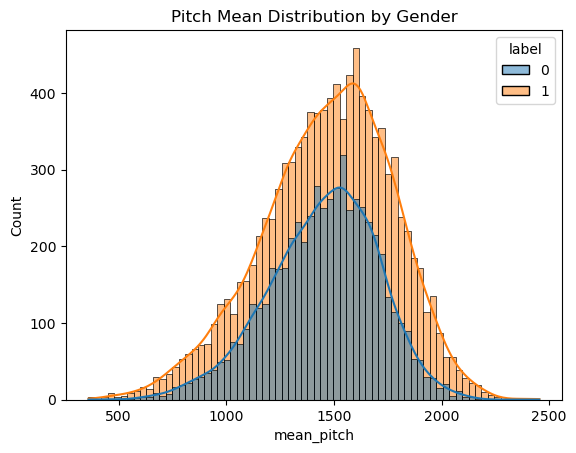

In [30]:
sns.histplot(data=df,x='mean_pitch',hue='label',kde=True)
plt.title("Pitch Mean Distribution by Gender")
plt.show()

#### Look for separation / overlap — strong separability ⇒ pitch is highly predictive

## 2. Boxplot – Pitch Mean by Gender

#### Compare medians & spread — wider female IQR and higher median expected

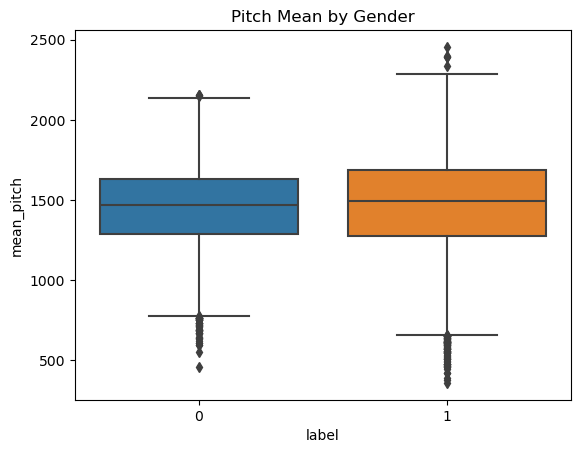

In [31]:
sns.boxplot(data=df,x='label',y='mean_pitch')
plt.title("Pitch Mean by Gender")
plt.show()

## 3. Violin Plot – MFCC_1_mean vs Gender

### MFCC_1 captures spectral slope.
### Helps detect tonal differences in gender

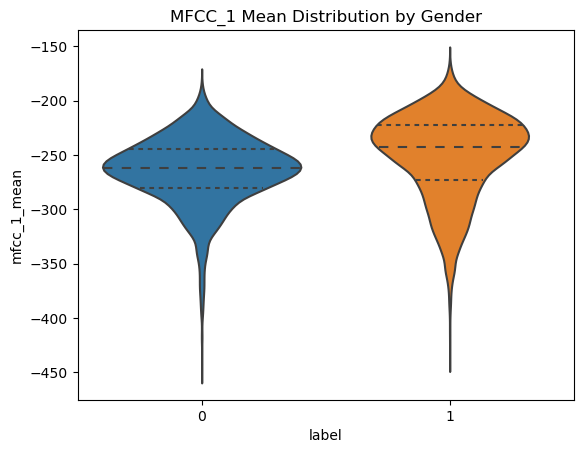

In [32]:
sns.violinplot(data=df,x='label',y='mfcc_1_mean',inner='quartile')
plt.title("MFCC_1 Mean Distribution by Gender")
plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew            16148 non-null  float64
 14  spectral_kurtosis     

## 4. Density Plot (KDE) – Spectral Centroid

### Shows how brightness differs between genders.

C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Spectral Centroid Density by Gender')

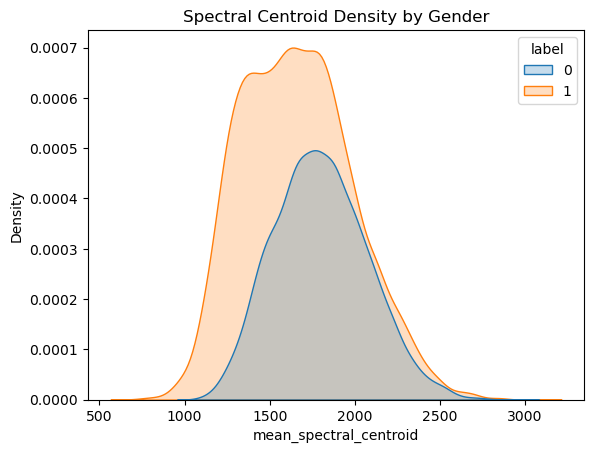

In [34]:
sns.kdeplot(data=df,x='mean_spectral_centroid',hue='label',fill=True)
plt.title("Spectral Centroid Density by Gender")

C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='std_spectral_centroid', ylabel='Density'>

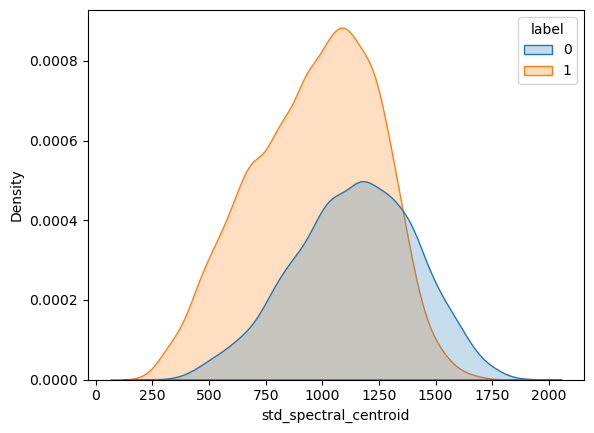

In [35]:
sns.kdeplot(data=df,x='std_spectral_centroid',hue='label',fill=True)

## 5. Correlation Heatmap (44 features → after selection maybe 20)

### Which features differ across gender

Text(0.5, 1.0, 'Correlation Heatmap')

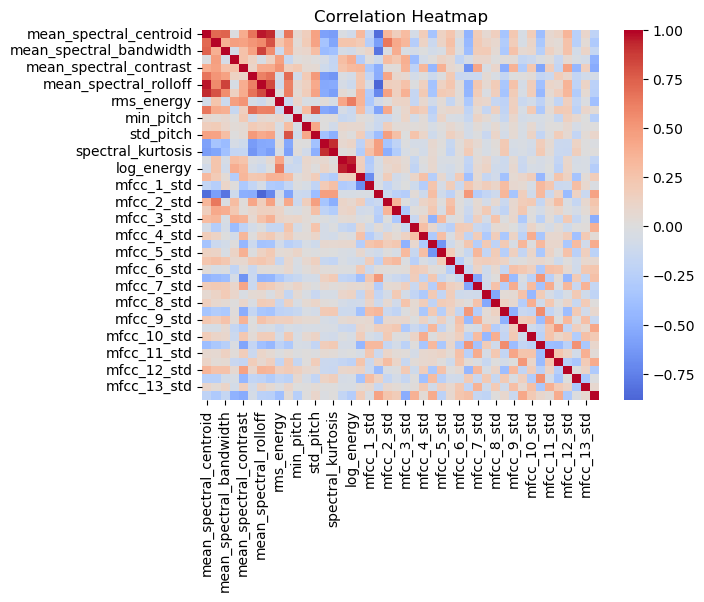

In [36]:
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")

## 6. Pairplot (scatter matrix)

### Shows natural separation line

C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\anoconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_

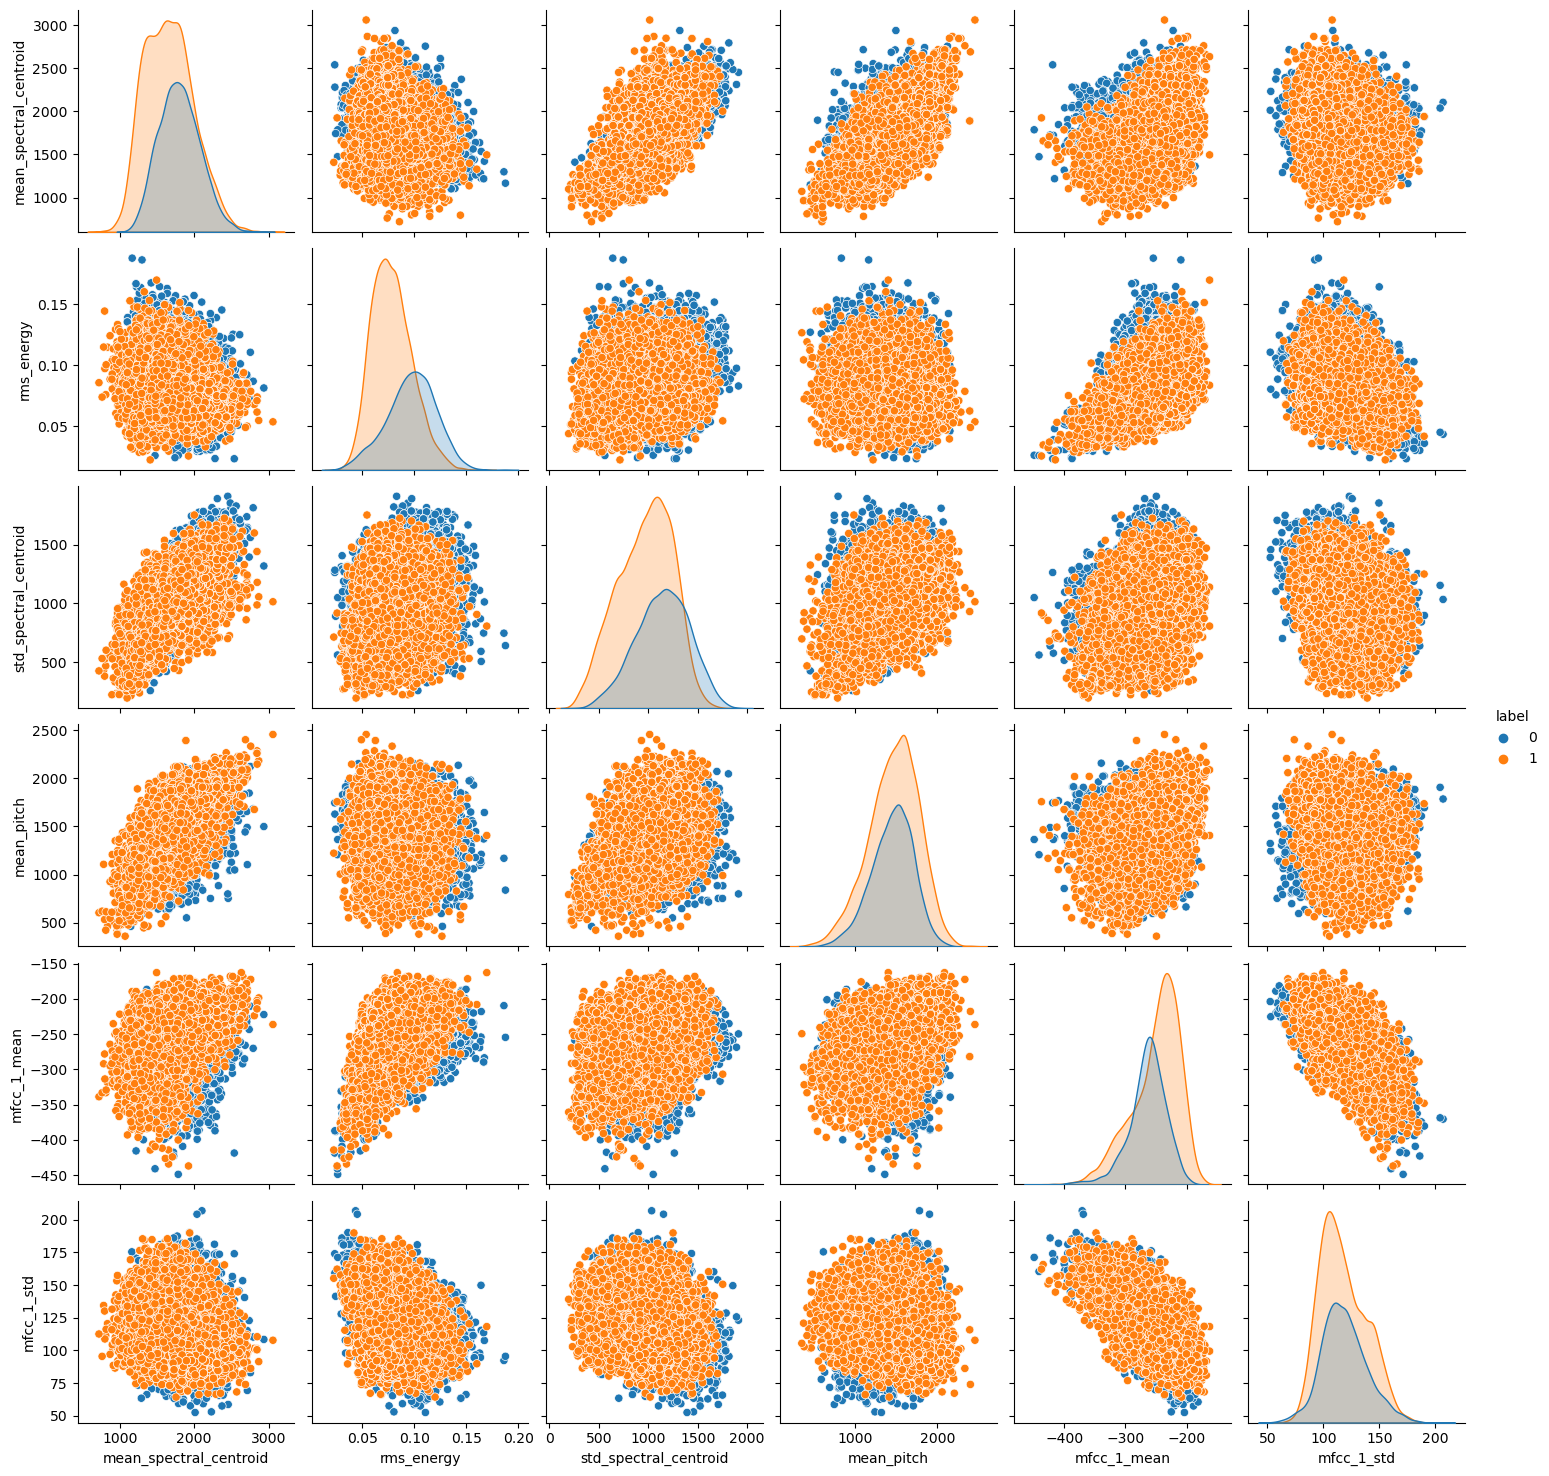

In [37]:
label_col='label'
pair_features  = ['mean_spectral_centroid','rms_energy','std_spectral_centroid','mean_pitch','mfcc_1_mean','mfcc_1_std']
sns.pairplot(df[pair_features + [label_col]], hue='label', diag_kind="kde")

## 7. PCA 2D Scatter Plot

### Plot first 2 principal components, color by class.

#### Shows natural clusters

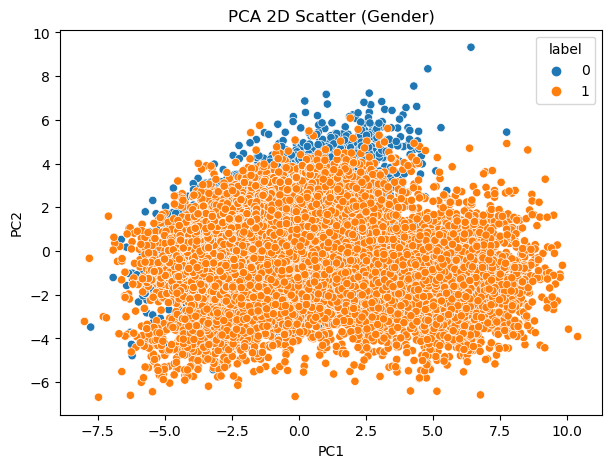

In [38]:
from sklearn.decomposition import PCA

features = df.drop(columns='label')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['label'])
plt.title("PCA 2D Scatter (Gender)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 8. UMAP or t-SNE Plot

### Better than PCA for non-linear separation.

#### Helps show speaker similarity

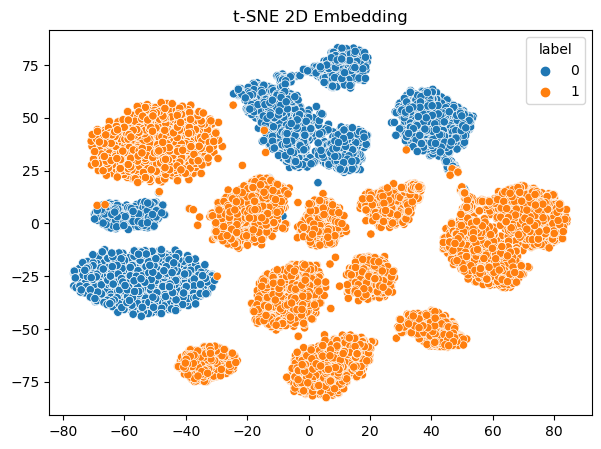

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['label'])
plt.title("t-SNE 2D Embedding")
plt.show()

## 9. Cluster Heatmap (Feature × Sample)

### Heatmap with hierarchical clustering.

#### Shows patterns like similar MFCC behavior per speaker

Excellent for multi-class EDA

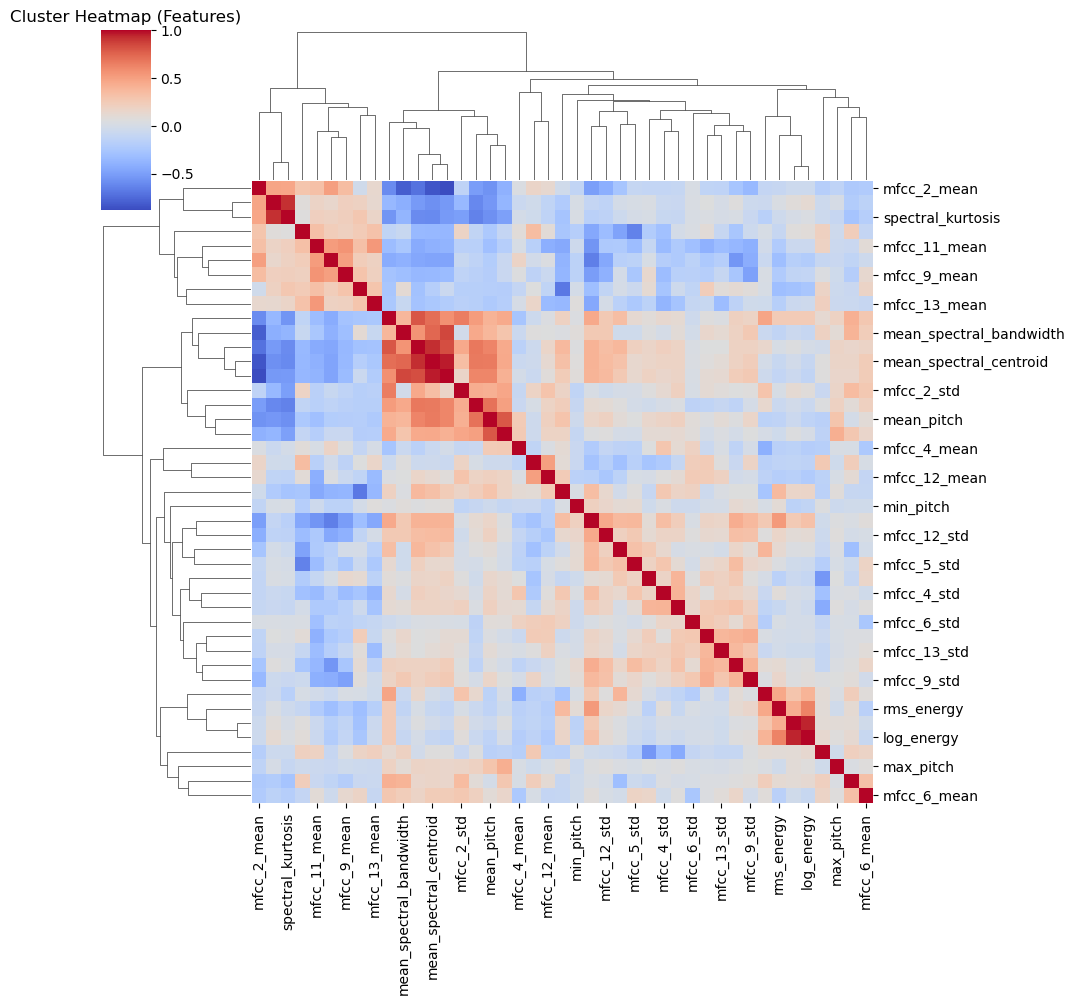

In [40]:
sns.clustermap(df[features.columns].corr(), cmap="coolwarm")
plt.title("Cluster Heatmap (Features)")
plt.show()

## 10. Radar Chart (Spider Plot) – Average Features per Class

### Shows feature signature of each speaker

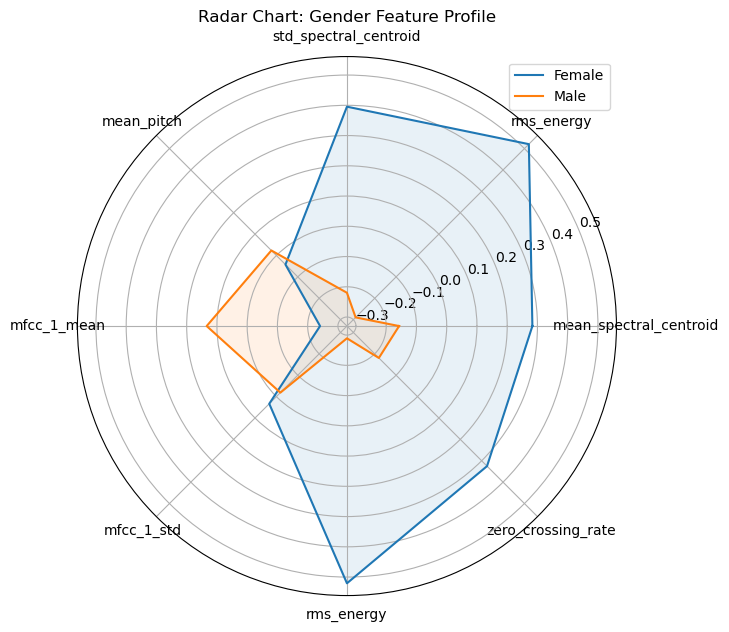

In [41]:
radar_feats = ['mean_spectral_centroid','rms_energy','std_spectral_centroid','mean_pitch','mfcc_1_mean','mfcc_1_std', 'rms_energy', 'spectral_rolloff', 'zero_crossing_rate']
radar_feats = [f for f in radar_feats if f in df.columns]

# Scale features
scaler = StandardScaler()
scaled = scaler.fit_transform(df[radar_feats])
scaled_df = pd.DataFrame(scaled, columns=radar_feats)

# Compute mean per gender
label_col= 'label'
female_mean = scaled_df[df[label_col] == 0].mean().values
male_mean = scaled_df[df[label_col] == 1].mean().values

labels = radar_feats
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
female_vals = np.concatenate((female_mean, [female_mean[0]]))
male_vals   = np.concatenate((male_mean, [male_mean[0]]))
angles     = angles + [angles[0]]

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, polar=True)

ax.plot(angles, female_vals, label='Female')
ax.fill(angles, female_vals, alpha=0.1)

ax.plot(angles, male_vals, label='Male')
ax.fill(angles, male_vals, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Radar Chart: Gender Feature Profile")
plt.legend()
plt.show()

# Model Training and Deployment 

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train,x_test,y_train,y_test = train_test_split(x_selected,y,test_size=0.2,random_state=42)

In [44]:
x_train.shape

(12918, 20)

In [45]:
x_test.shape

(3230, 20)

In [46]:
y_train.shape

(12918,)

In [47]:
y_test.shape

(3230,)

## CLUSTERING (UNSUPERVISED)

### K-Means Clustering

In [48]:
from sklearn.cluster import KMeans

In [49]:
wcss =[]
for i in range(1,22):
    km = KMeans(n_clusters=i)
    km.fit_predict(x_scaled)
    wcss.append(km.inertia_)

C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` w

In [50]:
wcss

[694364.0000000002,
 592812.8763607703,
 544912.2808430763,
 512193.23569573584,
 487199.9264984018,
 467027.5951815016,
 448328.5249192975,
 432850.8102021892,
 420654.81340868765,
 408985.86916133563,
 397659.2590984708,
 388304.0203903997,
 375562.51406662655,
 369673.1930643888,
 360161.4862478273,
 352756.05542847805,
 347062.8088080614,
 341684.7199929338,
 336008.3900655843,
 330017.4817574391,
 325938.89250829467]

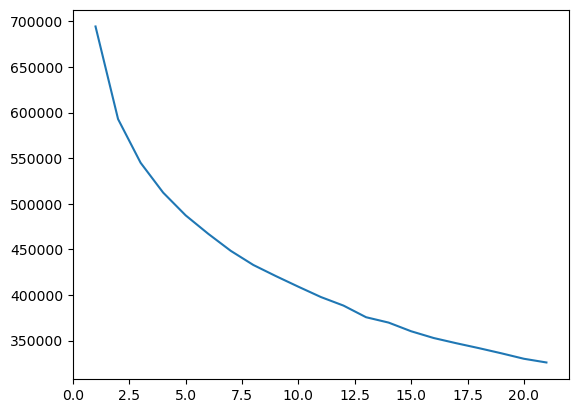

In [51]:
plt.plot(range(1,22),wcss)

In [52]:
km = KMeans(n_clusters=2,random_state=42)
km.fit(x_train)
label_km = km.labels_

print("KMeans Cluster Centers:\n", km.cluster_centers_)

C:\anoconda\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans Cluster Centers:
 [[ 0.80894165 -1.51373321 -0.5576545  -0.32245008 -0.07346047 -0.73423825
  -0.5903323   0.27186222  0.1714866  -0.52091602 -0.28176463  0.89919253
   0.42842519  1.23900545 -0.31636354 -0.22760904  1.17878654  1.12373385
  -0.10956422 -0.77369455]
 [-0.22949581  0.42012037  0.15766019  0.08339894  0.01835534  0.20803542
   0.16030619 -0.07433757 -0.04832266  0.14148355  0.07795879 -0.25363155
  -0.11532932 -0.34581761  0.08956281  0.05891778 -0.32847684 -0.31767515
   0.03216615  0.21898244]]


## DBSCAN Clustering

In [53]:
from sklearn.cluster import DBSCAN

In [54]:
dbscan = DBSCAN(eps=1.7,min_samples=5)
dbscan_labels = dbscan.fit_predict(x_train)

print("Unique clusters identified:", np.unique(dbscan_labels))

Unique clusters identified: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51]


# CLASSIFICATION MODELS (SUPERVISED)

## Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [56]:
log_reg = LogisticRegression()
log_reg.fit(x_train,y_train)

LogisticRegression()

In [57]:
y_pred_log = log_reg.predict(x_test)

In [58]:
accuracy_score(y_pred_log,y_test)

0.9798761609907121

In [59]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1163
           1       0.98      0.99      0.98      2067

    accuracy                           0.98      3230
   macro avg       0.98      0.98      0.98      3230
weighted avg       0.98      0.98      0.98      3230



## Decision Tree

In [60]:
from sklearn.tree import DecisionTreeClassifier

In [61]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [62]:
y_pred_dt = dt.predict(x_test)

In [63]:
accuracy_score(y_test,y_pred_dt)

0.9625386996904025

In [64]:
print(classification_report(y_test,y_pred_log))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1163
           1       0.98      0.99      0.98      2067

    accuracy                           0.98      3230
   macro avg       0.98      0.98      0.98      3230
weighted avg       0.98      0.98      0.98      3230



## Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
rd = RandomForestClassifier(n_estimators=300,random_state=42)
rd.fit(x_train,y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [67]:
y_pred_rd = rd.predict(x_test)

In [68]:
accuracy_score(y_test,y_pred_rd)

0.9941176470588236

In [69]:
print(classification_report(y_test,y_pred_rd))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1163
           1       0.99      1.00      1.00      2067

    accuracy                           0.99      3230
   macro avg       0.99      0.99      0.99      3230
weighted avg       0.99      0.99      0.99      3230



## SVM (RBF Kernel)

In [70]:
from sklearn.svm import SVC

In [71]:
svm = SVC(kernel ='rbf',probability=True,C=1,gamma ='scale')
svm.fit(x_train,y_train)

SVC(C=1, probability=True)

In [72]:
y_pred_svm = svm.predict(x_test)

In [73]:
accuracy_score(y_test,y_pred_svm)

0.9996904024767802

In [74]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1163
           1       1.00      1.00      1.00      2067

    accuracy                           1.00      3230
   macro avg       1.00      1.00      1.00      3230
weighted avg       1.00      1.00      1.00      3230



## XGBoost

In [75]:
from xgboost import XGBClassifier

In [76]:
xgb = XGBClassifier(eval_metric = 'logloss')
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [77]:
y_pred_xgb = xgb.predict(x_test)

In [78]:
accuracy_score(y_test,y_pred_xgb)

0.9947368421052631

In [79]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1163
           1       0.99      1.00      1.00      2067

    accuracy                           0.99      3230
   macro avg       0.99      0.99      0.99      3230
weighted avg       0.99      0.99      0.99      3230



## Hyperparameter Tuning

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
param_grid = {
    'n_estimators' : [100,200,300],
    'max_depth':[None,10,20],
    'min_samples_split' : [2,5]
}

In [82]:
grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=5, scoring='accuracy')
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [83]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.994503774980253


# Model Evaluation and Comparison: 

In [84]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    silhouette_score, adjusted_rand_score
)
from sklearn.utils.multiclass import unique_labels
import joblib
sns.set(style="whitegrid")

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled  = scaler.transform(x_test)

C:\anoconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\anoconda\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


=== Classification summary ===


,accuracy,precision,recall,f1
model,,,,
SVM,0.9997,1.0000,0.9995,0.9998
XGBoost,0.9947,0.9947,0.9971,0.9959
RandomForest,0.9938,0.9923,0.9981,0.9952
Logistic,0.9799,0.9803,0.9884,0.9843
Tree,0.9616,0.9677,0.9724,0.9701


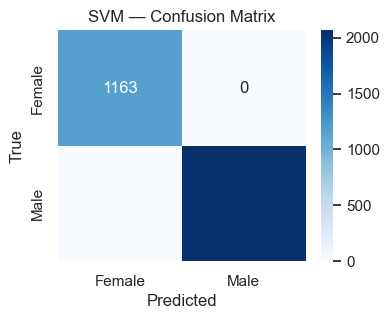

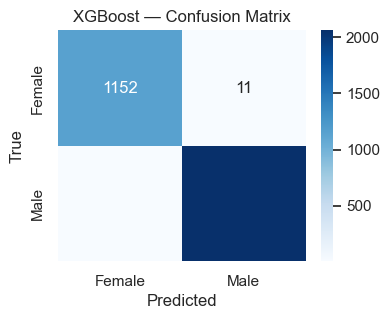

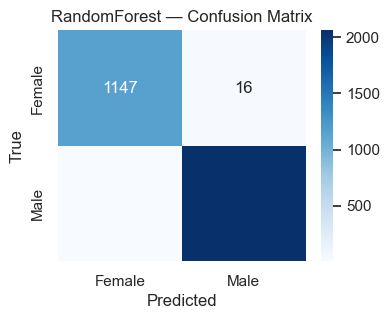


=== Clustering summary (silhouette) ===
{'kmeans_silhouette': None, 'dbscan_silhouette_nonnoise': 0.17683056513606094}

Best model by F1: SVM  (F1 = 0.9998)
Saved summary to model_comparison_summary.csv


In [86]:
# ===== Compact evaluation & comparison cell (run once) =====
sns.set()

# ---- CONFIG: point these to your variables ----
models = {"Logistic": log_reg, "Tree": dt, "RandomForest": rd, "SVM": svm, "XGBoost": xgb} 
# use the feature format you trained on (scaled vs unscaled). If you trained on scaled data, set use_scaled = True
use_scaled = True
X_test_use = X_test_scaled if use_scaled else x_test
X_train_for_clustering = X_train_scaled  # required for silhouette on kmeans/dbscan
# kmeans (fitted) and dbscan_labels (array for train rows) exist if you did clustering
# -------------------------------------------------

rows = []
predictions = {}
for name, model in models.items():
    # try to predict; if model expects different shape, try the other X (fallback)
    X_try = X_test_use
    try:
        y_pred = model.predict(X_try)
    except Exception:
        # try the other form (if available)
        alt = X_test if X_try is X_test_scaled else X_test_scaled
        y_pred = model.predict(alt)
    predictions[name] = y_pred
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    })

summary = pd.DataFrame(rows).set_index('model').round(4)
print("=== Classification summary ===")
display(summary.sort_values('f1', ascending=False))

# Confusion matrices (plot top 3 models by F1)
top3 = summary.sort_values('f1', ascending=False).head(3).index.tolist()
for name in top3:
    cm = confusion_matrix(y_test, predictions[name])
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Female','Male'], yticklabels=['Female','Male'])
    plt.title(f"{name} — Confusion Matrix")
    plt.ylabel("True"); plt.xlabel("Predicted")
    plt.show()

# Clustering metrics (if available)
clust_info = {}
try:
    km_labels = kmeans.predict(X_train_for_clustering) if hasattr(kmeans, "predict") else kmeans.labels_
    clust_info['kmeans_silhouette'] = silhouette_score(X_train_for_clustering, km_labels)
except Exception as e:
    clust_info['kmeans_silhouette'] = None

if 'dbscan_labels' in globals():
    try:
        db_labels = np.array(dbscan_labels)
        mask = db_labels != -1
        if mask.sum() > 1:
            clust_info['dbscan_silhouette_nonnoise'] = silhouette_score(X_train_for_clustering[mask], db_labels[mask])
        else:
            clust_info['dbscan_silhouette_nonnoise'] = None
    except Exception:
        clust_info['dbscan_silhouette_nonnoise'] = None

print("\n=== Clustering summary (silhouette) ===")
print(clust_info)

# Pick best model by F1
best_model_name = summary['f1'].idxmax()
print(f"\nBest model by F1: {best_model_name}  (F1 = {summary.loc[best_model_name,'f1']})")

# Save summary
summary.to_csv("model_comparison_summary.csv")
print("Saved summary to model_comparison_summary.csv")

In [87]:
import os
os.makedirs("models", exist_ok=True)

In [88]:
import joblib

joblib.dump(svm, "models/best_model_svm.joblib")
joblib.dump(scaler, "models/scaler_20_features.joblib")
joblib.dump(list(x_selected.columns), "models/selected_features_20.pkl")

print("Files saved!")

Files saved!


In [89]:
import os
os.listdir("models")

['best_model_svm.joblib',
 'dbscan_best.joblib',
 'dbscan_core_indices.pkl',
 'dbscan_core_nn.joblib',
 'dbscan_train_labels.csv',
 'kmeans_best.joblib',
 'kmeans_cluster_map.pkl',
 'kmeans_purity.csv',
 'kmeans_silhouette.csv',
 'kmeans_train_labels.csv',
 'scaler_20_features.joblib',
 'scaler_on_20_features.joblib',
 'selected_features_20.pkl']

In [90]:
model = joblib.load("models/best_model_svm.joblib")
scaler = joblib.load("models/scaler_20_features.joblib")
selected_features = joblib.load("models/selected_features_20.pkl")

In [91]:
# ===========================
# Save Best Clustering Model
# ===========================
import joblib, os
os.makedirs("models", exist_ok=True)

# Save KMeans model
joblib.dump(km, "models/kmeans_best.joblib")

# Save scaler (same used in classification)
joblib.dump(scaler, "models/scaler_20_features.joblib")

# Save selected feature list
joblib.dump(list(x_selected.columns), "models/selected_features_20.pkl")

print("KMeans clustering model saved correctly!")

# Optional: Compute silhouette score (just for your report)
from sklearn.metrics import silhouette_score
silhouette = silhouette_score(X_train_scaled, km.labels_)
print("KMeans Silhouette Score:", silhouette)

KMeans clustering model saved correctly!
KMeans Silhouette Score: 0.17610959405683313
